# Section 5.6

## Example 5.6.1

The antiderivative of $e^x$ is, of course, itself. That makes evaluation of $\int_0^1 e^x\,dx$ by the Fundamental Theorem trivial.

In [5]:
exact = exp(1) - 1

1.718281828459045

The Julia package `QuadGK` has an all-purpose numerical integrator that estimates the value without finding the antiderivative first. As you can see here, it's often just as accurate.

In [6]:
using QuadGK
Q, errest = quadgk(x -> exp(x), 0, 1)
@show Q;

Q = 1.7182818284590453


The numerical approach is also far more robust. For example, $e^{\,\sin x}$ has no useful antiderivative. But numerically, it's no more difficult.

In [7]:
Q, errest = quadgk(x -> exp(sin(x)), 0, 1)
@show Q;

Q = 1.6318696084180515


When you look at the graphs of these functions, what's remarkable is that one of these areas is basic calculus while the other is almost impenetrable analytically. From a numerical standpoint, they are practically the same problem.

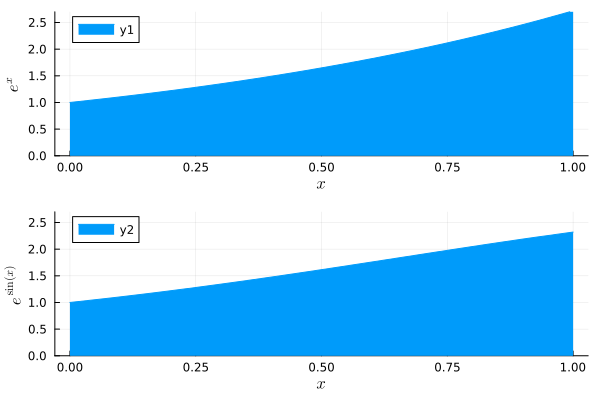

In [8]:
using Plots, LaTeXStrings
plot([exp, x -> exp(sin(x))], 0, 1, fill=0, layout=(2, 1),
    xlabel=L"x", ylabel=[L"e^x" L"e^{\sin(x)}"], ylim=[0, 2.7])

## Example 5.6.2

We will approximate the integral of the function $f(x)=e^{\sin 7x}$ over the interval $[0,2]$.

In [9]:
f(x) = exp(sin(7 * x));
a = 0;
b = 2;

In lieu of the exact value, we use the `QuadGK` package to find an accurate result.

```{tip}
:class: dropdown
If a function has multiple return values, you can use an underscore `_` to indicate a  return value you want to ignore.
```

In [10]:
using QuadGK
Q, _ = quadgk(f, a, b, atol=1e-14, rtol=1e-14);
println("Integral = $Q")

Integral = 2.6632197827615394


Here is the trapezoid result at $n=40$, and its error.

In [11]:
using FNCFunctions
T, t, y = FNC.trapezoid(f, a, b, 40)
@show (T, Q - T);

(T, Q - T) = (2.662302935602287, 0.0009168471592522209)


In order to check the order of accuracy, we increase $n$ by orders of magnitude and observe how the error decreases.

In [12]:
using PrettyTables

n = [10^n for n in 1:5]
err = zeros(length(n))
for (k, n) in enumerate(n)
    T, t, y = FNC.trapezoid(f, a, b, n)
    err[k] = Q - T
end
pretty_table((n=n, err=err); 
    column_labels=["n", "error"], backend=:html)

n,error
10,0.0120254
100,0.000147305
1000,1.47415e-6
10000,1.47416e-8
100000,1.47416e-10


Each increase by a factor of 10 in $n$ cuts the error by a factor of about 100, which is consistent with second-order convergence. Another check is that a log-log graph should give a line of slope $-2$ as $n\to\infty$.

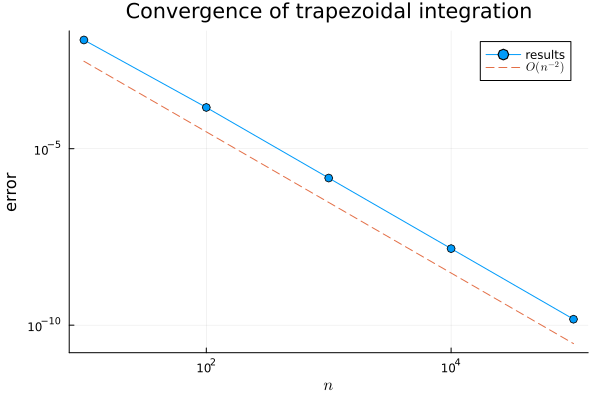

In [13]:
using Plots, LaTeXStrings
plot(n, abs.(err);
    m=:o, label="results",
    xaxis=(:log10, L"n"),  yaxis=(:log10, "error"),
    title="Convergence of trapezoidal integration")

# Add line for perfect 2nd order.
plot!(n, 3e-3 * (n / n[1]) .^ (-2), l=:dash, label=L"O(n^{-2})")

## Example 5.6.3

We estimate $\displaystyle\int_0^2 x^2 e^{-2x}\, dx$ using extrapolation. First we use `quadgk` to get an accurate value.

In [14]:
using QuadGK
f(x) = x^2 * exp(-2x);
a = 0;
b = 2;
Q, _ = quadgk(f, a, b, atol=1e-14, rtol=1e-14)
@show Q;

Q = 0.1904741736116139


We start with the trapezoid formula on $n=N$ nodes.

In [15]:
N = 20;       # the coarsest formula
n = N;
h = (b - a) / n;
t = h * (0:n);
y = f.(t);

We can now apply weights to get the estimate $T_f(N)$.

In [16]:
T = [h * (sum(y[2:n]) + y[1] / 2 + y[n+1] / 2)]

1-element Vector{Float64}:
 0.19041144993926784

Now we double to $n=2N$, but we only need to evaluate $f$ at every other interior node and apply {eq}`nc-doubling`.

In [17]:
n = 2n;
h = h / 2;
t = h * (0:n);
T = [T; T[end] / 2 + h * sum(f.(t[2:2:n]))]

2-element Vector{Float64}:
 0.19041144993926784
 0.19045880585951175

We can repeat the same code to double $n$ again.

In [18]:
n = 2n;
h = h / 2;
t = h * (0:n);
T = [T; T[end] / 2 + h * sum(f.(t[2:2:n]))]

3-element Vector{Float64}:
 0.19041144993926784
 0.19045880585951175
 0.1904703513046443

Let us now do the first level of extrapolation to get results from Simpson's formula. We combine the elements `T[i]` and `T[i+1]` the same way for $i=1$ and $i=2$.

In [19]:
S = [(4T[i+1] - T[i]) / 3 for i in 1:2]

2-element Vector{Float64}:
 0.19047459116625973
 0.19047419978635513

With the two Simpson values $S_f(N)$ and $S_f(2N)$ in hand, we can do one more level of extrapolation to get a sixth-order accurate result.

In [20]:
R = (16S[2] - S[1]) / 15

0.1904741736943615

We can make a triangular table of the errors:
```{tip}
:class: dropdown
The value `nothing` equals nothing except `nothing`.
```

In [21]:
using PrettyTables
err = [T .- Q [nothing; S .- Q] [nothing; nothing; R - Q]]
pretty_table(err; column_labels=["order 2", "order 4", "order 6"], backend=:html)

order 2,order 4,order 6
-6.27237e-5,nothing,nothing
-1.53678e-5,4.17555e-7,nothing
-3.82231e-6,2.61747e-8,8.27476e-11


If we consider the computational time to be dominated by evaluations of $f$, then we have obtained a result with about twice as many accurate digits as the best trapezoid result, at virtually no extra cost.